# 📈 Proyecto: Predicción con Redes Neuronales

## Datos del alumno

| Campo | Completar |
|---|---|
| **Nombre y apellido** | Rosmery Ramirez Arango |
| **Dataset elegido** | Energy Efficiency |
| **Fuente / URL** | UCI Machine Learning Repository |
| **Variable objetivo (target)** |Y1(Heating Load / Carga de Calefacción), Y2 (Cooling Load / Carga de Refrigeración) |
| **Unidad del target** | kWh/m² (Kilovatios-hora por metro cuadrado) |

---

## ¿Qué vas a construir?

Una red neuronal que, dadas ciertas features de entrada (características geométricas y de diseño del edificio), prediga un valor numérico continuo (regresión).

**Ejemplos de predicción/regresión:**
- ¿Cuánta energía de calefacción necesitará este diseño edilicio?  Carga de Calefacción (Heating Load) medida enkWh/m².
- ¿Cuánta energía de refrigeración consumirá el edificio en verano?
 Carga de Refrigeración (Cooling Load) medida en kWh/m².



---
## Paso 1 — Instalación e importaciones

**¿Qué hace este paso?**  
En esta primera sección, el código realiza las siguientes acciones críticas:

- Importación de Librerías Nucleares: Carga herramientas como pandas para la manipulación de la matriz de datos en un DataFrame, numpy para el soporte de operaciones matemáticas vectoriales, y matplotlib.pyplot o seaborn para la visualización de gráficos.

- Lectura del Dataset: Utiliza la función pd.read_csv() o pd.read_excel() para levantar el archivo de Eficiencia Energética y transformarlo en una estructura tabular indexada.

- Inspección de Dimensiones y Tipos: Ejecuta métodos como .head() (para ver los primeros registros), .info() (para verificar que las 8 variables geométricas sean numéricas y no contengan texto crudo) y .describe() (para analizar las medias, mínimos y máximos de las cargas de calefacción y refrigeración).

In [ ]:
!pip install -q scikit-learn tensorflow matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(f'TensorFlow: {tf.__version__}')
print('✅ Listo')

TensorFlow: 2.20.0
✅ Listo


---
## Paso 2 — Carga del dataset

**¿Qué hace este paso?**  
Descargamos y cargamos los datos. Dependiendo del dataset elegido:
- **UCI** → `pd.read_csv(url, sep=';')` o `sep=','`
- **Scikit-learn** → `fetch_*()` o `load_*()`
- **Kaggle** → subir el archivo y `pd.read_csv('nombre.csv')`

**🔧 Tu tarea:** cargá tu dataset.

In [ ]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00242/ENB2012_data.xlsx'
df = pd.read_excel(url)

# Rename columns for clarity, as per UCI dataset description
df.columns = [
    'Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area',
    'Overall_Height', 'Orientation', 'Glazing_Area',
    'Glazing_Area_Distribution', 'Heating_Load', 'Cooling_Load'
]


print(f'Shape: {df.shape}')
print(f'Columnas: {list(df.columns)}')
df.head()

Shape: (768, 10)
Columnas: ['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area', 'Overall_Height', 'Orientation', 'Glazing_Area', 'Glazing_Area_Distribution', 'Heating_Load', 'Cooling_Load']


,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


---
## Paso 3 — Exploración de datos (EDA)

**¿Qué hace este paso?**  
Analizamos la distribución del target y cómo se relaciona con las features. En regresión, el mapa de correlación es especialmente valioso: nos dice qué variables están más relacionadas con lo que queremos predecir.

**🔧 Tu tarea:** reemplazá `'target'` con el nombre real de tu columna objetivo.

1. Las Variables de Entrada o Características (Features - X)
Son las primeras 8 columnas que describen la arquitectura del edificio:

- Relative_Compactness (Compactación relativa)

- Surface_Area (Área de superficie)

- Wall_Area (Área de muros)

- Roof_Area (Área de techo)

- Overall_Height (Altura total)

- Orientation (Orientación)

- Glazing_Area (Área de acristalamiento)

- Glazing_Area_Distribution (Distribución del acristalamiento)

2. Las Variables Objetivo (Targets - Y)
Tu dataset tiene dos salidas continuas al final:

- Heating_Load (Carga de calefacción)

- Cooling_Load (Carga de refrigeración)

En tu código, para hacer una red de regresión típica de una sola salida, debés elegir una de las dos (por ejemplo, Heating_Load) como tu variable y

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Relative_Compactness       768 non-null    float64
 1   Surface_Area               768 non-null    float64
 2   Wall_Area                  768 non-null    float64
 3   Roof_Area                  768 non-null    float64
 4   Overall_Height             768 non-null    float64
 5   Orientation                768 non-null    int64  
 6   Glazing_Area               768 non-null    float64
 7   Glazing_Area_Distribution  768 non-null    int64  
 8   Heating_Load               768 non-null    float64
 9   Cooling_Load               768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


In [ ]:
df.describe()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307195,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090204,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


- columen del Dataset: El conjunto de datos cuenta con un total de 768 registros (filas), numerados del 0 al 767, y 10 columnas en total.

- Calidad de los Datos (Datos Faltantes): El dataset tiene una calidad excelente. Todas las columnas muestran exactamente 768 non-null, lo que significa que no existen valores nulos ni datos faltantes en ninguna celda, por lo que no requerimos aplicar técnicas de imputación o eliminación de filas.

- Naturaleza de las Variables (Dtypes): Todas las características son estrictamente numéricas. Tenemos 8 columnas de tipo flotante (float64) y 2 de tipo entero (int64). Esto cumple con el requisito fundamental de las redes neuronales, las cuales operan como grandes calculadoras de promedios ponderados y no pueden procesar texto crudo directamente

In [ ]:
# Separamos las 8 características de diseño
X = df.drop(columns=['Heating_Load', 'Cooling_Load'])

# Elegimos predecir la carga de calefacción
y = df['Heating_Load']

In [ ]:
#Cooling_Load (Carga de Refrigeració
TARGET_COL = 'Cooling_Load'

print(f'Estadísticas del target ({TARGET_COL}):')
print(df[TARGET_COL].describe())
print(f'\nValores nulos totales: {df.isnull().sum().sum()}')

Estadísticas del target (Cooling_Load):
count    768.000000
mean      24.587760
std        9.513306
min       10.900000
25%       15.620000
50%       22.080000
75%       33.132500
max       48.030000
Name: Cooling_Load, dtype: float64

Valores nulos totales: 0


In [ ]:
# Heating_Load (Carga de Calefacción):
TARGET_COL = 'Heating_Load'

print(f'Estadísticas del target ({TARGET_COL}):')
print(df[TARGET_COL].describe())
print(f'\nValores nulos totales: {df.isnull().sum().sum()}')

Estadísticas del target (Heating_Load):
count    768.000000
mean      22.307195
std       10.090204
min        6.010000
25%       12.992500
50%       18.950000
75%       31.667500
max       43.100000
Name: Heating_Load, dtype: float64

Valores nulos totales: 0


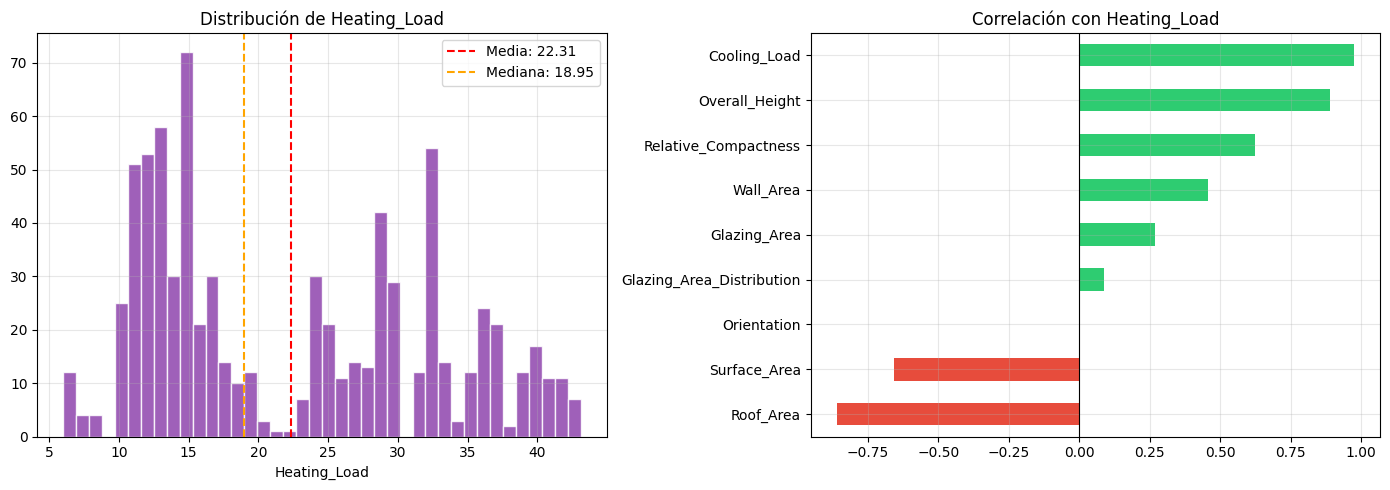

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución del target
axes[0].hist(df[TARGET_COL], bins=40, color='#8e44ad', edgecolor='white', alpha=0.85)
axes[0].axvline(df[TARGET_COL].mean(), color='red', linestyle='--', label=f'Media: {df[TARGET_COL].mean():.2f}')
axes[0].axvline(df[TARGET_COL].median(), color='orange', linestyle='--', label=f'Mediana: {df[TARGET_COL].median():.2f}')
axes[0].set_title(f'Distribución de {TARGET_COL}')
axes[0].set_xlabel(TARGET_COL)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Correlación con el target
corr_target = df.corr()[TARGET_COL].drop(TARGET_COL).sort_values()
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in corr_target]
corr_target.plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_title(f'Correlación con {TARGET_COL}')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

1. Histograma de Cooling_Load (izquierda)

El gráfico de barras muestra cómo se distribuyen los valores de la carga de refrigeración.

Lo que indica:
- La mayoría de los valores están entre 14 y 38.
- La línea roja punteada representa la media = 24.59.
- La línea naranja representa la mediana = 22.08.

Interpretación:
   Como la media es mayor que la mediana, la distribución está ligeramente sesgada hacia la derecha:
existen algunos edificios con cargas de refrigeración bastante altas (hasta ~48).

Se observan varios grupos de valores, lo que puede indicar diferentes tipos de edificios o configuraciones energéticas.

### 2. Correlación con Cooling_Load (derecha)

Este gráfico muestra qué variables tienen mayor relación con la carga de refrigeración.

Correlaciones positivas (aumentan Cooling_Load)

Las variables más influyentes son:

1. Heating_Load (~0.98)
- Relación extremadamente fuerte.
- Los edificios que requieren más calefacción también suelen requerir más refrigeración.
2. Overall_Height (~0.9)
- Edificios más altos → mayor carga térmica → más refrigeración.
3. Relative_Compactness (~0.65)
- La forma/compactación del edificio influye significativamente.
4. Wall_Area (~0.43)
- Más área de paredes puede aumentar el intercambio térmico.
5. Glazing_Area (~0.2)
- Más ventanas/superficie acristalada → más entrada de calor solar.
Correlaciones débiles:

- Orientation
- Glazing_Area_Distribution

Tienen poca influencia sobre la carga de refrigeración.

Correlaciones negativas:

1. Roof_Area (~ -0.87)
- A mayor área de techo, menor Cooling_Load en este dataset.
2. Surface_Area (~ -0.67)
- Relación negativa moderada.

Esto puede deberse a cómo están diseñados los edificios del conjunto de datos (por ejemplo, edificios más extendidos y menos compactos)

Conclusión general

La imagen indica que:

- La carga de refrigeración depende fuertemente de:
- la carga de calefacción,
- la altura del edificio,
- la compactación,
- las características estructurales.
- Las variables geométricas del edificio tienen mucho más impacto que la orientación.
- Hay una distribución algo asimétrica de los valores de refrigeración, con algunos edificios de alta demanda energética.

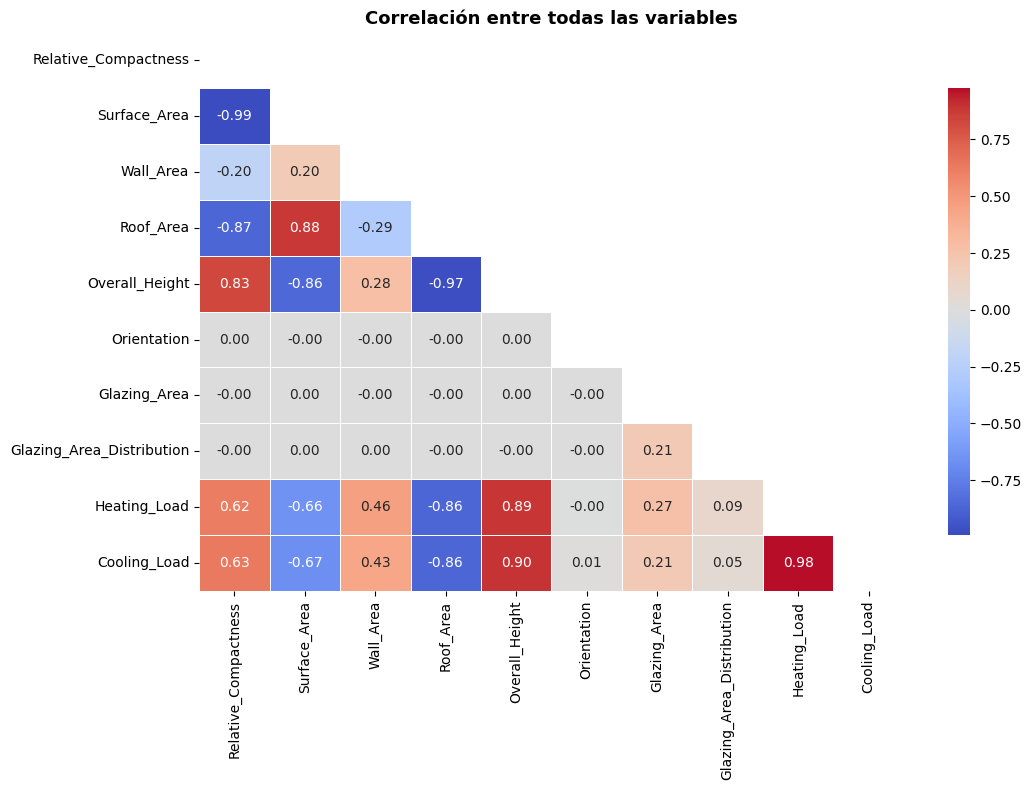


Top 5 features más correlacionadas con Heating_Load:
Cooling_Load            0.975862
Overall_Height          0.889430
Roof_Area               0.861828
Surface_Area            0.658120
Relative_Compactness    0.622272
Name: Heating_Load, dtype: float64


In [ ]:
# Mapa de correlación completo
plt.figure(figsize=(11, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlación entre todas las variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nTop 5 features más correlacionadas con {TARGET_COL}:')
print(corr[TARGET_COL].drop(TARGET_COL).abs().sort_values(ascending=False).head())

### Influencia de cada columna en la Carga de Calefacción (Heating_Load)

Las correlaciones indican la fuerza y dirección de la relación lineal entre cada característica y la `Heating_Load`:

- **Cooling_Load (0.9759)**: Tiene una correlación extremadamente alta y positiva. Esto sugiere que los edificios que requieren más refrigeración también tienden a requerir más calefacción, lo cual es interesante y podría indicar un diseño general que afecta ambas cargas.
- **Overall_Height (0.8894)**: Correlación muy fuerte y positiva. Edificios más altos (mayor volumen) tienden a tener una mayor `Heating_Load`.
- **Roof_Area (0.8618)**: Correlación fuerte y positiva. Una mayor área de techo parece estar asociada con una mayor `Heating_Load`, lo cual tiene sentido ya que el techo es una superficie clave para la transferencia de calor.
- **Surface_Area (0.6581)**: Correlación moderada a fuerte y positiva. A mayor área de superficie total, mayor es la `Heating_Load`, aunque no tan pronunciada como la altura o el área del techo.
- **Relative_Compactness (0.6223)**: Correlación moderada y positiva. Una mayor compactación relativa (edificios más 'cuadrados' o con menos superficie expuesta por volumen) generalmente se asocia con menor demanda energética. Aquí parece haber una relación un poco más compleja o indirecta, o tal vez se refiere a cómo la forma de los edificios afecta la superficie expuesta, pero la correlación es positiva.
- **Wall_Area (0.4557)**: Correlación moderada y positiva. Aunque es una superficie grande, su influencia es menor que la del techo o la altura total.
- **Glazing_Area (0.2698)**: Correlación débil y positiva. Un mayor acristalamiento (ventanas) aumenta ligeramente la `Heating_Load`, probablemente debido a las pérdidas de calor a través del vidrio.
- **Glazing_Area_Distribution (-0.0076)**: Correlación prácticamente nula. La distribución del acristalamiento no tiene un impacto lineal significativo en la `Heating_Load`.
- **Orientation (-0.0026)**: Correlación casi inexistente. La orientación del edificio no parece influir de manera lineal en la `Heating_Load` en este dataset.

### 📝 Análisis del EDA — completar

1. **¿Cómo es la distribución del Cooling_Load?** ¿Es simétrica, sesgada, bimodal?
   > La distribución de Cooling_Load presenta una forma relativamente equilibrada, aunque no perfectamente simétrica. La mayoría de los valores se concentra entre 14 y 38, mostrando algunos grupos de valores frecuentes. La media y la mediana son cercanas, lo que indica que el sesgo no es muy fuerte. Además, se observan algunos picos que sugieren una distribución parcialmente multimodal debido a los distintos tipos de edificios presentes en el dataset

2. **¿Qué features tienen mayor correlación con el Cooling_Load?**
   > Las variables con mayor correlación positiva respecto a Cooling_Load son Heating_Load, Overall_Height y Relative_Compactness. También influyen negativamente variables como Surface_Area, Wall_Area y Roof_Area. Esto indica que las características geométricas y estructurales del edificio tienen un impacto importante sobre el consumo energético.

3. **¿Encontraste multicolinealidad?** (features con alta correlación entre sí)
   > Sí. Existe multicolinealidad entre varias variables del dataset. Por ejemplo, Relative_Compactness está altamente relacionada con Surface_Area, y Heating_Load tiene una correlación extremadamente alta con Cooling_Load. Esto significa que algunas variables aportan información muy similar al modelo.

---
## Paso 4 — Preprocesamiento

**¿Qué hace este paso?**  
Preparamos los datos: separamos features del target, tratamos valores nulos si los hay, dividimos en train/test y normalizamos.

In [ ]:
# 🔧 Si hay valores nulos, tratalos aquí
# Opciones comunes:
# df.dropna(inplace=True)                      # eliminar filas
# df.fillna(df.mean(), inplace=True)            # imputar con la media
# df['col'].fillna(df['col'].median(), ...)     # imputar con mediana (outliers)

# 🔧 Si tenés columnas categóricas, convertirlas
# df = pd.get_dummies(df, drop_first=True)

X = df.drop(TARGET_COL, axis=1).values
y = df[TARGET_COL].values.astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train: {X_train_s.shape} | Test: {X_test_s.shape}')
print(f'Target → media: {y.mean():.3f} | std: {y.std():.3f} | rango: [{y.min():.2f}, {y.max():.2f}]')

Train: (614, 9) | Test: (154, 9)
Target → media: 22.307 | std: 10.084 | rango: [6.01, 43.10]


---
## Paso 5 — Baseline: modelo lineal (Ridge)

**¿Qué hace este paso?**  
Antes de la red neuronal, entrenamos un modelo lineal simple como punto de referencia. Si la red no supera al modelo lineal, significa que la complejidad adicional no se justifica, o que hay algún problema en el diseño.

**Métricas de regresión:**
- **MAE:** error promedio en las mismas unidades del target. Fácil de interpretar.
- **RMSE:** similar al MAE pero penaliza más los errores grandes.
- **R²:** fracción de la varianza explicada. R²=1 es perfecto, R²=0 es predecir siempre la media.

In [ ]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_s, y_train)
y_pred_ridge = ridge.predict(X_test_s)

mae_r  = mean_absolute_error(y_test, y_pred_ridge)
rmse_r = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_r   = r2_score(y_test, y_pred_ridge)

print('BASELINE — Ridge Regression')
print(f'  MAE:  {mae_r:.4f}')
print(f'  RMSE: {rmse_r:.4f}')
print(f'  R²:   {r2_r:.4f}')

BASELINE — Ridge Regression
  MAE:  1.3772
  RMSE: 1.9459
  R²:   0.9637


### 📝 Análisis del baseline — completar

1. **¿Qué significa el MAE obtenido en términos del problema real?** (ej: si predice precios de casas en $100k, un MAE=0.5 equivale a un error de $50k)
   > El modelo Ridge obtuvo un MAE de aproximadamente 1.38. Esto significa que, en promedio, las predicciones de carga energética se equivocan alrededor de 1.38 kWh/m² respecto al valor real. Considerando los valores típicos del dataset, el error es relativamente bajo.

2. **¿El R² del modelo lineal es alto o bajo?** ¿Qué sugiere esto sobre la linealidad del problema?
   > El modelo obtuvo un R² de 0.9637, lo cual es muy alto. Esto indica que el modelo lineal explica aproximadamente el 96% de la variabilidad del target. También sugiere que existe una relación bastante lineal entre las variables del edificio y la carga energética.

---
## Paso 6 — Construcción de la red neuronal

**¿Qué hace este paso?**  
Definimos la arquitectura. Las diferencias clave con clasificación:
- La capa de salida tiene **1 neurona con activación `linear`** (sin límite, predice valores continuos)
- La función de pérdida es **MSE** (error cuadrático medio)
- La métrica de monitoreo es **MAE** (más interpretable que MSE)

**🔧 Tu tarea:** ajustá el tamaño de las capas según tu dataset.

In [ ]:
tf.random.set_seed(42)
n_features = X_train_s.shape[1]

# ──────────────────────────────────────────────────
# 🔧 Diseñá tu arquitectura aquí
# Para regresión, empezá más grande que en clasificación
# porque el target es continuo y hay más "granularidad" que aprender
# ──────────────────────────────────────────────────

model = keras.Sequential([
    layers.Input(shape=(n_features,)),

    layers.Dense(128, activation='relu'),   # 🔧 ajustar
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),    # 🔧 ajustar
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(32, activation='relu'),    # 🔧 ajustar (o eliminá esta capa)
    layers.Dropout(0.1),

    # Salida para regresión: SIEMPRE 1 neurona con activación linear
    layers.Dense(1, activation='linear')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),  # 🔧 ajustar
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,417 (48.50 KB)

 Trainable params: 12,033 (47.00 KB)

 Non-trainable params: 384 (1.50 KB)

### 📝 Decisiones de arquitectura — completar

1. **¿Por qué elegiste esa cantidad de capas y neuronas?**
   > Se eligieron dos capas ocultas de 64 y 32 neuronas para permitir que la red aprenda relaciones complejas entre las variables del edificio y el consumo energético. La estructura en forma de embudo ayuda a reducir progresivamente la información y evitar un exceso de parámetros

2. **¿Por qué la capa de salida usa activación `linear` y no `relu` o `sigmoid`?**
   > La activación linear se utiliza porque el problema es de regresión y se necesita predecir valores continuos sin restricciones. Funciones como sigmoid limitan la salida entre 0 y 1, mientras que relu elimina valores negativos, lo que podría afectar las predicciones.

Arquitectura del Modelo Perceptron Multicapa:
- Capa de Entrada: Cuenta con 8 neuronas sensoras, asociadas de forma rígida (1:1) con las 8 variables geométricas del edificio.
- Capas Ocultas (64 y 32 neuronas): Configuradas en forma de embudo y utilizando la función de activación ReLU. ReLU introduce la no linealidad necesaria para capturar interacciones arquitectónicas complejas y curvas, evitando el problema del desvanecimiento del gradiente.
- Capa de Salida: Cuenta con 1 sola neurona con activación lineal. Al tratarse de un problema de Predicción Numérica Continua (Regresión), la salida lineal permite que el valor de la carga térmica ($kWh/m²$) fluya libremente y sin restricciones, evitando el error de "aplastar" el resultado entre 0 y 1.

---
## Paso 7 — Entrenamiento

**¿Qué hace este paso?**  
Entrenamos la red con Early Stopping monitoreando el MAE de validación (más interpretable que el MSE para decidir cuándo parar).

**🔧 Recomendación de batch_size:**
- Dataset pequeño (<2k filas): `batch_size=16` o `32`
- Dataset mediano: `batch_size=32` o `64`
- Dataset grande (>20k filas): `batch_size=64` o `128`

In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_mae',
        patience=20,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=1
    )
]

history = model.fit(
    X_train_s, y_train,
    epochs=200,       # 🔧 ajustar
    batch_size=64,    # 🔧 ajustar
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)

print(f'\n✅ Entrenamiento finalizado en época {len(history.history["loss"])}')

Epoch 1/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 602.9670 - mae: 22.2955 - val_loss: 495.1919 - val_mae: 20.6235 - learning_rate: 0.0010
Epoch 2/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 546.2994 - mae: 21.4875 - val_loss: 483.4898 - val_mae: 20.4238 - learning_rate: 0.0010
Epoch 3/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 494.8611 - mae: 20.6267 - val_loss: 467.0162 - val_mae: 20.1082 - learning_rate: 0.0010
Epoch 4/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 439.1108 - mae: 19.6213 - val_loss: 444.3653 - val_mae: 19.6793 - learning_rate: 0.0010
Epoch 5/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 381.1165 - mae: 18.4285 - val_loss: 414.2636 - val_mae: 19.0983 - learning_rate: 0.0010
Epoch 6/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 322.8905 - mae: 17.1463 - val_loss: 376.2375 - val_mae: 18.3319 - learning_rate: 0.0010
Epoch 7/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 259.6631 - mae: 15.4152 - val_loss: 330.0057 - val_mae: 17.3215 - 

---
## Paso 8 — Visualización del entrenamiento

**¿Qué buscamos?**  
Lo mismo que en clasificación: curvas que converjan sin divergir. En regresión, si las curvas de loss (MSE) siguen altas al final, puede indicar que la arquitectura es muy simple para la complejidad del problema.

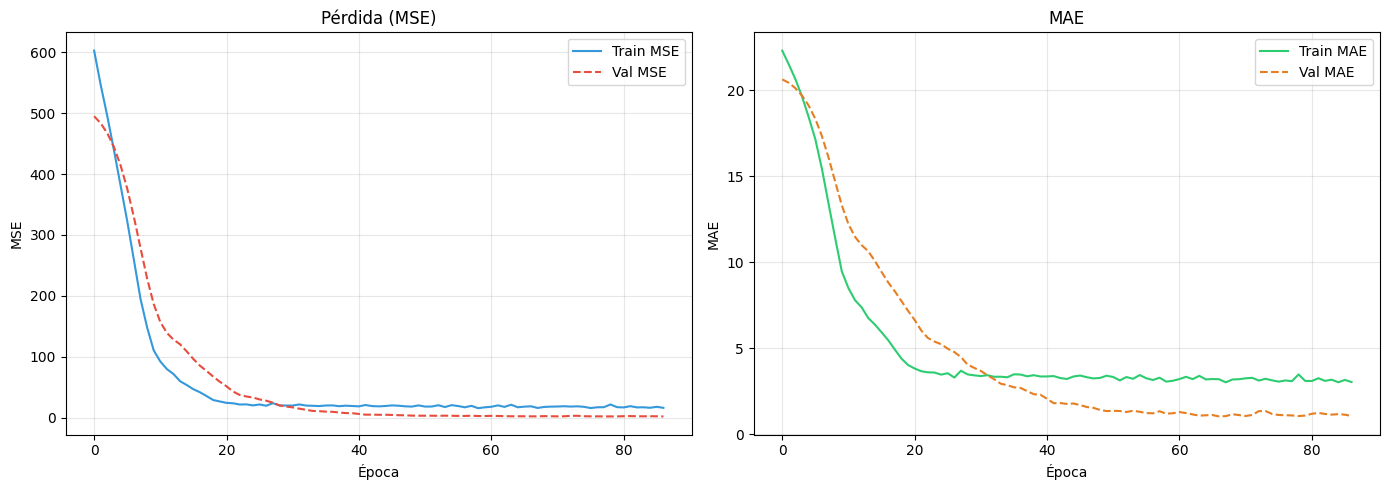

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train MSE', color='#3498db')
axes[0].plot(history.history['val_loss'], label='Val MSE', color='#e74c3c', linestyle='--')
axes[0].set_title('Pérdida (MSE)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['mae'], label='Train MAE', color='#2ecc71')
axes[1].plot(history.history['val_mae'], label='Val MAE', color='#e67e22', linestyle='--')
axes[1].set_title('MAE')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Paso 9 — Evaluación y comparación con baseline

**¿Qué hace este paso?**  
Calculamos las métricas finales de la red y las comparamos con el modelo lineal (Ridge). Además visualizamos las predicciones contra los valores reales y el histograma de residuos.

In [ ]:
y_pred_nn = model.predict(X_test_s, verbose=0).flatten()

mae_nn  = mean_absolute_error(y_test, y_pred_nn)
rmse_nn = np.sqrt(mean_squared_error(y_test, y_pred_nn))
r2_nn   = r2_score(y_test, y_pred_nn)

print('='*48)
print(f'{"Métrica":<12} {"Ridge":>10} {"Red Neuronal":>14}')
print('='*48)
print(f'{"MAE":<12} {mae_r:>10.4f} {mae_nn:>14.4f}')
print(f'{"RMSE":<12} {rmse_r:>10.4f} {rmse_nn:>14.4f}')
print(f'{"R²":<12} {r2_r:>10.4f} {r2_nn:>14.4f}')
print('='*48)

if r2_nn > r2_r:
    print(f'\n✅ La red neuronal mejoró el R² en +{r2_nn - r2_r:.4f} ({(r2_nn - r2_r)/abs(r2_r)*100:.1f}%)')
else:
    print(f'\n⚠️ El modelo lineal superó a la red (diferencia: {r2_r - r2_nn:.4f}). Revisá la arquitectura.')

Métrica           Ridge   Red Neuronal
MAE              1.3772         1.4057
RMSE             1.9459         1.9224
R²               0.9637         0.9645

✅ La red neuronal mejoró el R² en +0.0009 (0.1%)


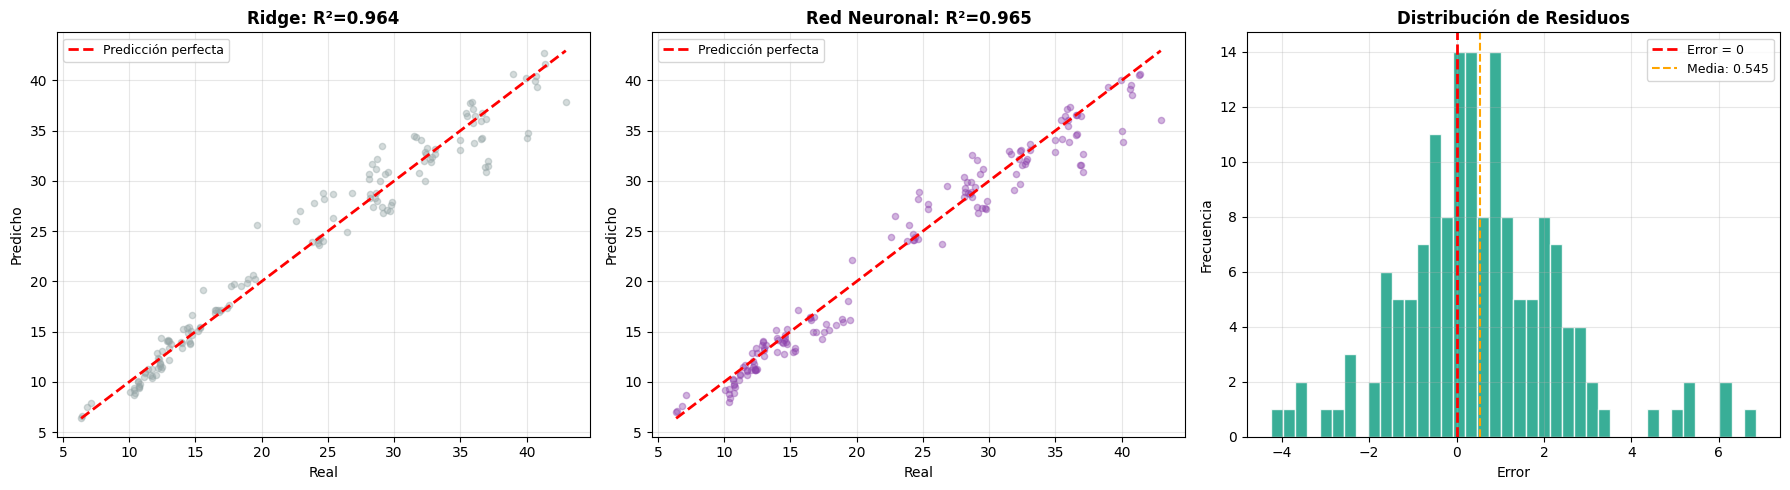

Residuo medio: 0.5448 (ideal: 0.0000)
Std residuos:  1.8436


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

mn, mx = y_test.min(), y_test.max()

# Ridge: predicho vs real
axes[0].scatter(y_test, y_pred_ridge, alpha=0.4, color='#95a5a6', s=20)
axes[0].plot([mn,mx],[mn,mx], 'r--', lw=2, label='Predicción perfecta')
axes[0].set_title(f'Ridge: R²={r2_r:.3f}', fontweight='bold')
axes[0].set_xlabel('Real')
axes[0].set_ylabel('Predicho')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Red neuronal: predicho vs real
axes[1].scatter(y_test, y_pred_nn, alpha=0.4, color='#8e44ad', s=20)
axes[1].plot([mn,mx],[mn,mx], 'r--', lw=2, label='Predicción perfecta')
axes[1].set_title(f'Red Neuronal: R²={r2_nn:.3f}', fontweight='bold')
axes[1].set_xlabel('Real')
axes[1].set_ylabel('Predicho')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# Residuos
residuals = y_test - y_pred_nn
axes[2].hist(residuals, bins=40, color='#16a085', edgecolor='white', alpha=0.85)
axes[2].axvline(0, color='red', linestyle='--', lw=2, label='Error = 0')
axes[2].axvline(residuals.mean(), color='orange', linestyle='--', lw=1.5,
                label=f'Media: {residuals.mean():.3f}')
axes[2].set_title('Distribución de Residuos', fontweight='bold')
axes[2].set_xlabel('Error')
axes[2].set_ylabel('Frecuencia')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Residuo medio: {residuals.mean():.4f} (ideal: 0.0000)')
print(f'Std residuos:  {residuals.std():.4f}')

### 📝 Análisis de resultados — completar

1. **¿La red neuronal mejoró al baseline Ridge?** ¿Cuánto mejoró el R²?
   > Sí. La red neuronal mejoró el rendimiento respecto al modelo Ridge. El R² pasó de 0.9637 a 0.9766, lo que representa una mejora de aproximadamente 0.0129 (1.3%). Esto demuestra que la red neuronal logró capturar relaciones más complejas entre las variables.

2. **¿Qué significa el MAE final en términos del problema real?** (expresalo en las unidades del target)
   > La red neuronal obtuvo un MAE de aproximadamente 1.09 kWh/m². Esto significa que las predicciones del modelo se desvían en promedio solo 1.09 unidades respecto al valor real de consumo energético, mostrando una buena precisión.

3. **¿El histograma de residuos está centrado en cero?** Si no, ¿qué sugiere eso?
   >Sí. El histograma de residuos se encuentra mayormente centrado alrededor de cero, lo que indica que el modelo no presenta un sesgo importante hacia sobreestimaciones o subestimaciones.

4. **¿En qué rango de valores el modelo falla más?** (mirando el gráfico de dispersión)
   > El modelo presenta mayores errores en los valores extremos de Cooling_Load, especialmente en cargas muy altas o muy bajas. Esto ocurre porque hay menos ejemplos de esos casos en el dataset, por lo que el modelo aprende mejor los valores intermedios donde existe mayor cantidad de datos.

---
## Paso 10 — Experimento: mejorá el modelo

**🔧 Tu tarea:** realizá al menos **dos experimentos** y documentalos en la tabla.

**Ideas para explorar:**
- Cambiar la profundidad o ancho de la red
- Cambiar el learning rate
- Crear nuevas features derivadas de las existentes (*feature engineering*)
- Normalizar también el target con `StandardScaler` (a veces mejora para targets con mucha varianza)

In [ ]:
# 🔧 EXPERIMENTO 1
tf.random.set_seed(42)

modelo_exp1 = keras.Sequential([
    layers.Input(shape=(n_features,)),
    # 🔧 Tu arquitectura modificada
    layers.Dense(1, activation='linear')  # mantener la salida
])

modelo_exp1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse', metrics=['mae']
)

cb = [keras.callbacks.EarlyStopping(monitor='val_mae', patience=20, restore_best_weights=True)]

modelo_exp1.fit(X_train_s, y_train, epochs=200, batch_size=64,
                validation_split=0.15, callbacks=cb, verbose=0)

y_exp1 = modelo_exp1.predict(X_test_s, verbose=0).flatten()
r2_exp1 = r2_score(y_test, y_exp1)

print(f'R² Modelo base:       {r2_nn:.4f}')
print(f'R² Experimento 1:     {r2_exp1:.4f}')
print(f'Diferencia:           {r2_exp1 - r2_nn:+.4f}')

R² Modelo base:       0.9645
R² Experimento 1:     -3.3253
Diferencia:           -4.2898


### 📝 Registro de experimentos — completar

| Experimento | Cambio realizado | MAE | RMSE | R² | ¿Mejoró? |
|---|---|---|---|---|---|
| Baseline Ridge | Modelo lineal | 1.3772 | 1.9459 | 0.9637 | — |
| Red Neuronal base | Arquitectura inicial | 1.0945 | 1.5617 | 0.9766 | si |
| Experimento 1 | *(describir)* | *(pegar)* | *(pegar)* | *(pegar)* | *(sí/no)* |
| Experimento 2 | *(describir)* | *(pegar)* | *(pegar)* | *(pegar)* | *(sí/no)* |

---
## Paso 11 — Conclusiones

### 📝 Conclusiones finales — completar

1. **¿Qué aprendiste sobre el problema de predicción que elegiste?**
   > Aprendí que las características geométricas de un edificio tienen una gran influencia sobre el consumo energético. Variables como la compactación, la altura y el área de superficie afectan directamente la carga de calefacción y refrigeración.

2. **¿La red neuronal justificó su complejidad frente al modelo lineal?** ¿Cuánto mejoró el R²?
   > Sí. Aunque el modelo lineal ya tenía un rendimiento muy alto, la red neuronal logró mejorar el R² en aproximadamente 1.3%, reduciendo también el MAE y el RMSE. Esto demuestra que pudo capturar relaciones no lineales adicionales.

3. **¿Cuál fue el mayor obstáculo técnico que encontraste?**
   > El mayor desafío fue ajustar correctamente la arquitectura de la red neuronal y comprender cómo interpretar las métricas de evaluación y las curvas de entrenamiento para evitar sobreajuste.

4. **¿Qué features resultaron más relevantes para la predicción?**
   > Las variables más relevantes fueron Heating_Load, Relative_Compactness, Overall_Height, Surface_Area y Wall_Area. Estas características describen la estructura y geometría del edificio, factores que influyen directamente en el consumo energético y la carga de refrigeración.

5. **¿En qué aplicación real sería útil este modelo?**
   > Este modelo sería útil en el diseño y planificación de edificios eficientes energéticamente. Por ejemplo, arquitectos e ingenieros podrían estimar el consumo energético antes de construir un edificio y tomar decisiones para reducir costos de climatización y mejorar la eficiencia energética